# Population shifts in Finland

## 1. The datasets I used:

- 11re, Population by age, sex, and area: 11re, Population according to age (1-year) and sex by area, 1972–2025
- 12dy, Births, deaths, and natural increase: 12dy, Vital statistics and population by area, 1990–2024
- 11a7, Migration: Migration by Area, Year, Sex, Age, and Information.

By combining all three factors, we can then distinguish which is due to aging, which is due to low birth rates, which is due to people leaving the country, and only then can we predict the future.

- Official forecast for comparison/benchmark: Population projection 2024

## 2. Data Loading & Cleaning


### 2.1 Dataset 11re - Data loading and cleaning

In [1]:
import pandas as pd

df = pd.read_csv(
    "11re.csv",
    encoding="latin1",
    skiprows=1
)

print(df.columns.tolist()[:5])
df.head()

['Area', 'Age', 'Total 1972 Population 31 Dec', 'Total 1973 Population 31 Dec', 'Total 1974 Population 31 Dec']


,Area,Age,Total 1972 Population 31 Dec,Total 1973 Population 31 Dec,Total 1974 Population 31 Dec,Total 1975 Population 31 Dec,Total 1976 Population 31 Dec,Total 1977 Population 31 Dec,Total 1978 Population 31 Dec,Total 1979 Population 31 Dec,...,Total 2016 Population 31 Dec,Total 2017 Population 31 Dec,Total 2018 Population 31 Dec,Total 2019 Population 31 Dec,Total 2020 Population 31 Dec,Total 2021 Population 31 Dec,Total 2022 Population 31 Dec,Total 2023 Population 31 Dec,Total 2024 Population 31 Dec,Total 2025 Population 31 Dec
0,WHOLE COUNTRY,Total,4653401,4678761,4702387,4720492,4730836,4746967,4758088,4771292,...,5503297,5513130,5517919,5525292,5533793,5548241,5563970,5603851,5635971,5652881
1,WHOLE COUNTRY,0 - 14,1075779,1058250,1043625,1030544,1017056,1005231,989786,976009,...,894178,890424,882234,871036,860861,851794,840328,832232,820287,807730
2,WHOLE COUNTRY,15 - 24,854636,839623,825876,812722,800817,788245,779793,770267,...,633704,623807,616543,610615,606642,607961,612345,623027,632917,641814
3,WHOLE COUNTRY,25 - 44,1259351,1295674,1327845,1352351,1372007,1395429,1419544,1442723,...,1375752,1389906,1403384,1413710,1420282,1425736,1437327,1457344,1472108,1476247
4,WHOLE COUNTRY,45 - 64,1005480,1010716,1013291,1016303,1016682,1016901,1014615,1014715,...,1449688,1429675,1410921,1398657,1390070,1383714,1379459,1381872,1381842,1379596


In [2]:
import pandas as pd

df = pd.read_csv(
    "11re.csv",
    encoding="latin1",
    skiprows=1
)

# clean column names
df.columns = df.columns.str.strip()

# bỏ whole country
df = df[df["Area"] != "WHOLE COUNTRY"].copy()

# rename
df = df.rename(columns={
    "Area": "area",
    "Age": "age_group"
})

# melt wide -> long
df_long = df.melt(
    id_vars=["area", "age_group"],
    var_name="year",
    value_name="population"
)

# lấy year
df_long["year"] = df_long["year"].astype(str).str.extract(r"(\d{4})")
df_long["year"] = pd.to_numeric(df_long["year"], errors="coerce")

# population sang numeric
df_long["population"] = (
    df_long["population"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
df_long["population"] = pd.to_numeric(df_long["population"], errors="coerce")

print(df_long.head())
print(df_long.shape)

   area age_group  year  population
0  Akaa     Total  1972       15973
1  Akaa    0 - 14  1972        3568
2  Akaa   15 - 24  1972        3148
3  Akaa   25 - 44  1972        3884
4  Akaa   45 - 64  1972        3688
(99792, 4)


In [3]:
df_long.head()
df_long["area"].nunique()
df_long["age_group"].unique()

<StringArray>
['Total', '0 - 14', '15 - 24', '25 - 44', '45 - 64', '65 -']
Length: 6, dtype: str


#### Data cleaning - 11re


#### Normalize age_group

In [4]:
df_long["age_group"] = df_long["age_group"].str.replace(" ", "")

#### Pivot to main board

In [5]:
df_pivot = df_long.pivot_table(
    index=["area", "year"],
    columns="age_group",
    values="population"
).reset_index()

df_pivot.head()

age_group,area,year,0-14,15-24,25-44,45-64,65-,Total
0,Akaa,1972,3568.0,3148.0,3884.0,3688.0,1685.0,15973.0
1,Akaa,1973,3517.0,3023.0,4034.0,3679.0,1749.0,16002.0
2,Akaa,1974,3428.0,2929.0,4120.0,3674.0,1818.0,15969.0
3,Akaa,1975,3434.0,2810.0,4218.0,3669.0,1925.0,16056.0
4,Akaa,1976,3300.0,2747.0,4256.0,3675.0,1993.0,15971.0


#### Rename for easier use.

In [6]:
df_pivot = df_pivot.rename(columns={
    "Total": "pop_total",
    "0-14": "age_0_14",
    "15-24": "age_15_24",
    "25-44": "age_25_44",
    "45-64": "age_45_64",
    "65-": "age_65_plus"
})

#### Create feature

In [7]:
df_pivot["aging_rate"] = df_pivot["age_65_plus"] / df_pivot["pop_total"] #Aging rate
df_pivot["youth_rate"] = df_pivot["age_0_14"] / df_pivot["pop_total"] #Youth rate
df_pivot["growth_rate"] = df_pivot.groupby("area")["pop_total"].pct_change() #Growth rate

16632 rows: ~300 municipalities × ~50+ years
11 columns, including:
- area
- year
- age groups
- features i created

In [8]:
df_pivot.head()
df_pivot.shape

(16632, 11)

#### Visualization and Insight - 11re

#### Visualize population trend

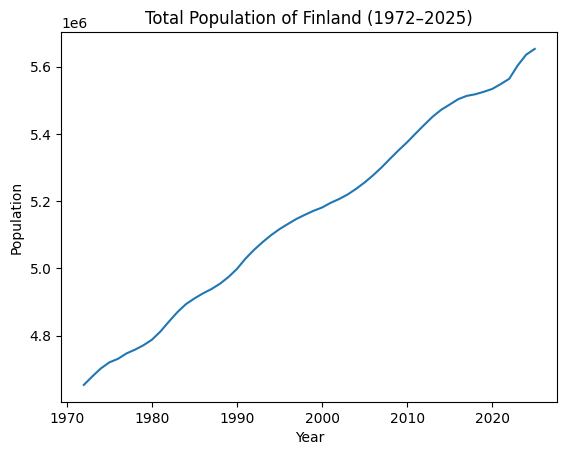

In [9]:
import matplotlib.pyplot as plt

finland = df_pivot.groupby("year")["pop_total"].sum()

plt.figure()
finland.plot()
plt.title("Total Population of Finland (1972–2025)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.show()

#### Aging trend

When does aging begin to accelerate sharply?
When does population growth slow down?

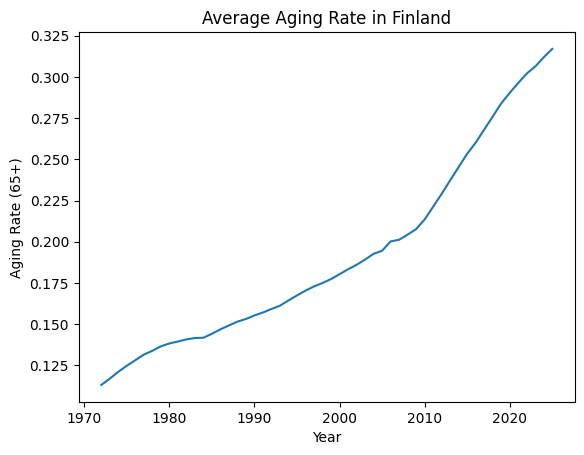

In [10]:
aging = df_pivot.groupby("year")["aging_rate"].mean()

plt.figure()
aging.plot()
plt.title("Average Aging Rate in Finland")
plt.xlabel("Year")
plt.ylabel("Aging Rate (65+)")
plt.show()

#### Top / Bottom municipalities

Oldest Top:

In [11]:
latest = df_pivot[df_pivot["year"] == df_pivot["year"].max()]

latest.sort_values("aging_rate", ascending=False).head(10)

age_group,area,year,age_0_14,age_15_24,age_25_44,age_45_64,age_65_plus,pop_total,aging_rate,youth_rate,growth_rate
12581,Rääkkylä,2025,119.0,63.0,214.0,529.0,905.0,1830.0,0.494536,0.065027,-0.027113
2591,Ilomantsi,2025,334.0,201.0,591.0,1091.0,2076.0,4293.0,0.483578,0.077801,-0.020310
11285,Puumala,2025,140.0,103.0,277.0,556.0,1005.0,2081.0,0.482941,0.067275,-0.009519
14147,Sysmä,2025,241.0,171.0,434.0,926.0,1595.0,3367.0,0.473715,0.071577,-0.017795
6155,Kuhmoinen,2025,155.0,115.0,272.0,502.0,935.0,1979.0,0.472461,0.078322,-0.028950
2105,Hyrynsalmi,2025,170.0,108.0,270.0,503.0,933.0,1984.0,0.470262,0.085685,-0.008991
11015,Posio,2025,205.0,160.0,337.0,821.0,1303.0,2826.0,0.461076,0.072541,-0.018068
14525,Tervo,2025,135.0,49.0,205.0,363.0,636.0,1388.0,0.458213,0.097262,0.000000
1565,Hartola,2025,219.0,108.0,325.0,651.0,1098.0,2401.0,0.457309,0.091212,-0.032635
11231,Puolanka,2025,200.0,134.0,320.0,627.0,1041.0,2322.0,0.448320,0.086133,-0.009808


The fastest growing city

In [12]:
latest.sort_values("growth_rate", ascending=False).head(10)

age_group,area,year,age_0_14,age_15_24,age_25_44,age_45_64,age_65_plus,pop_total,aging_rate,youth_rate,growth_rate
10313,Pelkosenniemi,2025,92.0,34.0,193.0,246.0,367.0,932.0,0.393777,0.098712,0.024176
11501,Pyhäntä,2025,354.0,188.0,376.0,339.0,421.0,1678.0,0.250894,0.210965,0.022547
971,Föglö,2025,78.0,39.0,98.0,132.0,165.0,512.0,0.322266,0.152344,0.019920
5291,Kittilä,2025,987.0,659.0,1965.0,1821.0,1541.0,6973.0,0.220995,0.141546,0.019892
14903,Turku,2025,25233.0,32144.0,66508.0,43423.0,42325.0,209633.0,0.201900,0.120367,0.017275
13985,Sund,2025,152.0,87.0,201.0,294.0,284.0,1018.0,0.278978,0.149312,0.016983
10691,Pirkkala,2025,3823.0,2365.0,5748.0,5434.0,4003.0,21373.0,0.187292,0.178871,0.015730
1835,Helsinki,2025,96742.0,78474.0,235221.0,161171.0,122784.0,694392.0,0.176822,0.139319,0.015166
647,Espoo,2025,56019.0,40123.0,102069.0,77513.0,49992.0,325716.0,0.153483,0.171987,0.014910
12797,Saltvik,2025,305.0,148.0,388.0,467.0,494.0,1802.0,0.274140,0.169256,0.013498


- After observing the chart, I think Finland is aging, even though the population is still growing.
- I also see that the growth rate is quite stable and consistent.
- As for the Agin rate, from 1970 to around 2005 it only increased slightly, but after around 2010, it started to increase rapidly.
- As for population growth, it seems to be slowing down. From 2010 it seem to increase quite rapidly, but from 2020, it has slowed down, and the graph has started to flatten.

### 2.2. Dataset 12dy - Data loading and cleaning


1. Preview the original file
- In this step, I wanted to view the actual file before processing, and I discovered I had to use encoding="latin-1" because the file contains Finnish characters (ä, ö) which cannot be read by default using UTF-8 (similar to 11re before).

- Shape 5.37 has 35 columns for years and 2 columns for identifiers.

In [13]:
#STEP 1: Preview the original file
import pandas as pd

raw_12dy = pd.read_csv("12dy.csv", skiprows=1, nrows=5, encoding="latin-1")
print("Shape:", raw_12dy.shape)
print("\nColumns:")
for col in raw_12dy.columns:
    print(" ", repr(col))

Shape: (5, 37)

Columns:
  'Area'
  'Information'
  '1990'
  '1991'
  '1992'
  '1993'
  '1994'
  '1995'
  '1996'
  '1997'
  '1998'
  '1999'
  '2000'
  '2001'
  '2002'
  '2003'
  '2004'
  '2005'
  '2006'
  '2007'
  '2008'
  '2009'
  '2010'
  '2011'
  '2012'
  '2013'
  '2014'
  '2015'
  '2016'
  '2017'
  '2018'
  '2019'
  '2020'
  '2021'
  '2022'
  '2023'
  '2024'


2. check Information column
- In these two steps, I want to see the unique values ​​of the Information column.

- This column has three things, like the output.

In [14]:
#STEP 2: check valuesin Information
raw_12dy_full = pd.read_csv("12dy.csv", skiprows=1, encoding="latin-1")

print("Unique values in 'Information':")
for val in raw_12dy_full["Information"].unique():
    print(" ", repr(val))

Unique values in 'Information':
  'Live births'
  'Deaths'
  'Natural increase'


3. Just read a few lines to understand the actual structure.

In [15]:
# STEP 3: Read a few lines..
print(raw_12dy_full.head(9).to_string())

            Area       Information   1990   1991   1992   1993   1994   1995   1996   1997   1998   1999   2000   2001   2002   2003   2004   2005   2006   2007   2008   2009   2010   2011   2012   2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023   2024
0  WHOLE COUNTRY       Live births  65549  65395  66731  64826  65231  63067  60723  59329  57108  57574  56742  56189  55555  56630  57758  57745  58840  58729  59530  60430  60980  59961  59493  58134  57232  55472  52814  50321  47577  45613  46463  49594  44951  43383  43720
1  WHOLE COUNTRY            Deaths  50058  49294  49844  50988  48000  49280  49167  49108  49262  49345  49339  48550  49418  48996  47600  47928  48065  49077  49094  49883  50887  50585  51707  51472  52186  52492  53923  53722  54527  53949  55488  57659  63219  61339  58267
2  WHOLE COUNTRY  Natural increase  15491  16101  16887  13838  17231  13787  11556  10221   7846   8229   7403   7639   6137   7634  10158   9817  10775   9652

In [16]:
# STEP 4: Clean and reshape 12dy ===

# 4.1 Rename the column to be consistent with df_pop
df_12dy_raw = raw_12dy_full.copy()
df_12dy_raw.columns = df_12dy_raw.columns.str.strip()
df_12dy_raw = df_12dy_raw.rename(columns={"Area": "area", "Information": "information"})

# 4.2 Remove WHOLE COUNTRY (maintain consistency with df_pop)
df_12dy_raw = df_12dy_raw[df_12dy_raw["area"] != "WHOLE COUNTRY"].reset_index(drop=True)

# 4.3 Melt: wide to long
year_cols = [col for col in df_12dy_raw.columns if col.isdigit()]

df_12dy_long = df_12dy_raw.melt(
    id_vars=["area", "information"],
    value_vars=year_cols,
    var_name="year",
    value_name="value"
)

# 4.4 Type Conversion
df_12dy_long["year"] = df_12dy_long["year"].astype(int)
df_12dy_long["value"] = pd.to_numeric(df_12dy_long["value"], errors="coerce")

# 4.5 Pivot: Each piece of information is typed into a separate column.
df_vital = df_12dy_long.pivot_table(
    index=["area", "year"],
    columns="information",
    values="value"
).reset_index()

# 4.6 change collumne name
df_vital.columns.name = None
df_vital = df_vital.rename(columns={
    "Live births":       "births",
    "Deaths":            "deaths",
    "Natural increase":  "natural_increase"
})

# 4.7 check
print("Shape:", df_vital.shape)
print("\nColumns:", df_vital.columns.tolist())
print("\nSample:")
print(df_vital.head(6).to_string())
print("\nNull counts:")
print(df_vital.isnull().sum())

Shape: (10780, 5)

Columns: ['area', 'year', 'deaths', 'births', 'natural_increase']

Sample:
   area  year  deaths  births  natural_increase
0  Akaa  1990   191.0   206.0              15.0
1  Akaa  1991   159.0   180.0              21.0
2  Akaa  1992   191.0   203.0              12.0
3  Akaa  1993   176.0   192.0              16.0
4  Akaa  1994   168.0   200.0              32.0
5  Akaa  1995   184.0   167.0             -17.0

Null counts:
area                0
year                0
deaths              0
births              0
natural_increase    0
dtype: int64


In [17]:
#Use consistent aliases.
df_pop = df_pivot.copy()

print("df_pop ready:", df_pop.shape)
print("Years:", df_pop["year"].min(), "→", df_pop["year"].max())
print("Areas:", df_pop["area"].nunique())

df_pop ready: (16632, 11)
Years: 1972 → 2025
Areas: 308


5. check area alignment.
- Area alignment must be checked because if the area names don't match exactly (Akaa vs AKAA), the merge will generate a large number of NaNs without any warning.
- The result is 308/308 matched, 0 mismatch.

In [18]:
#STEP 5

areas_pop = set(df_pop["area"].unique())
areas_vital = set(df_vital["area"].unique())

only_in_pop   = areas_pop - areas_vital
only_in_vital = areas_vital - areas_pop
in_both       = areas_pop & areas_vital

print(f"Areas in df_pop:    {len(areas_pop)}")
print(f"Areas in df_vital:  {len(areas_vital)}")
print(f"Matched (in both):  {len(in_both)}")
print(f"\nOnly in df_pop (not in df_vital): {len(only_in_pop)}")
print(f"Only in df_vital (not in df_pop): {len(only_in_vital)}")

if only_in_pop:
    print("\nSample - only in df_pop:", sorted(only_in_pop)[:10])
if only_in_vital:
    print("Sample - only in df_vital:", sorted(only_in_vital)[:10])

Areas in df_pop:    308
Areas in df_vital:  308
Matched (in both):  308

Only in df_pop (not in df_vital): 0
Only in df_vital (not in df_pop): 0


6.
- Note before merging: df_pop contains years 1972–2025, while df_vital only contains 1990–2024. After merging, years outside that range will have NaN in the births/deaths column, this is normal and not an error.
- how="left": Keeps the entire history of df_pop (1972–2025). Years outside the range of df_vital will have NaN at births/deaths.
- Results: shape (16632, 14), 5852 NaN in vital columns, correct for 308 areas × 19 years with no vital data.

In [19]:
# STEP 6: Merge df_pop + df_vital.
df_merged = df_pop.merge(
    df_vital,
    on=["area", "year"],
    how="left"
)

# check the result
print("Shape:", df_merged.shape)
print("\nColumns:", df_merged.columns.tolist())
print("\nNull counts:")
print(df_merged.isnull().sum())
print("\nYear range with vital data:")
has_vital = df_merged[df_merged["births"].notna()]
print(f"  {has_vital['year'].min()} → {has_vital['year'].max()}")
print(f"  Rows with vital data: {len(has_vital)}")

Shape: (16632, 14)

Columns: ['area', 'year', 'age_0_14', 'age_15_24', 'age_25_44', 'age_45_64', 'age_65_plus', 'pop_total', 'aging_rate', 'youth_rate', 'growth_rate', 'deaths', 'births', 'natural_increase']

Null counts:
area                   0
year                   0
age_0_14               0
age_15_24              0
age_25_44              0
age_45_64              0
age_65_plus            0
pop_total              0
aging_rate             0
youth_rate             0
growth_rate          308
deaths              5852
births              5852
natural_increase    5852
dtype: int64

Year range with vital data:
  1990 → 2024
  Rows with vital data: 10780


7. Working subset
- For analysis and modeling, only use years with complete data from both sources. Do not delete df_merged, keep it for later use with the entire history.

In [20]:
#STEP 7: create working subset (1990–2024)
df = df_merged[
    (df_merged["year"] >= 1990) &
    (df_merged["year"] <= 2024)
].copy().reset_index(drop=True)

print("Working dataset shape:", df.shape)
print("Years:", df["year"].min(), "→", df["year"].max())
print("Areas:", df["area"].nunique())
print("\nNull counts:")
print(df.isnull().sum())
print("\nSample:")
print(df[df["area"] == "Lahti"].tail(5).to_string())

Working dataset shape: (10780, 14)
Years: 1990 → 2024
Areas: 308

Null counts:
area                0
year                0
age_0_14            0
age_15_24           0
age_25_44           0
age_45_64           0
age_65_plus         0
pop_total           0
aging_rate          0
youth_rate          0
growth_rate         0
deaths              0
births              0
natural_increase    0
dtype: int64

Sample:
       area  year  age_0_14  age_15_24  age_25_44  age_45_64  age_65_plus  pop_total  aging_rate  youth_rate  growth_rate  deaths  births  natural_increase
4370  Lahti  2020   17188.0    13372.0    30131.0    29452.0      29841.0   119984.0    0.248708    0.143252     0.001344  1276.0   967.0            -309.0
4371  Lahti  2021   17096.0    13214.0    30007.0    29472.0      30238.0   120027.0    0.251927    0.142435     0.000358  1400.0  1023.0            -377.0
4372  Lahti  2022   16742.0    13435.0    30059.0    29349.0      30590.0   120175.0    0.254545    0.139314     0.001233  

### 2.3 Dataset 11a7: Data loading and cleaning

In [21]:
# STEP 1: check the file
raw_11a7 = pd.read_csv("11a7.csv", skiprows=1, nrows=5, encoding="latin-1")
print("Shape:", raw_11a7.shape)
print("\nColumns:")
for col in raw_11a7.columns:
    print(" ", repr(col))

Shape: (5, 39)

Columns:
  'Area'
  'Sex'
  'Age'
  'Information'
  '1990'
  '1991'
  '1992'
  '1993'
  '1994'
  '1995'
  '1996'
  '1997'
  '1998'
  '1999'
  '2000'
  '2001'
  '2002'
  '2003'
  '2004'
  '2005'
  '2006'
  '2007'
  '2008'
  '2009'
  '2010'
  '2011'
  '2012'
  '2013'
  '2014'
  '2015'
  '2016'
  '2017'
  '2018'
  '2019'
  '2020'
  '2021'
  '2022'
  '2023'
  '2024'


In [22]:
# 11a7 STEP 2: check value of columm 
raw_11a7_full = pd.read_csv("11a7.csv", skiprows=1, encoding="latin-1")

for col in ["Sex", "Age", "Information"]:
    vals = raw_11a7_full[col].unique()
    print(f"\nUnique '{col}' ({len(vals)} values):")
    for v in vals:
        print(" ", repr(v))


Unique 'Sex' (1 values):
  'Total'

Unique 'Age' (1 values):
  'Total'

Unique 'Information' (3 values):
  'Immigration to Finland'
  'Emigration from Finland'
  'Net migration'


In [23]:
# 11a7 STEP 3
print(raw_11a7_full.head(9).to_string())

            Area    Sex    Age              Information   1990   1991   1992   1993   1994   1995   1996   1997   1998   1999   2000   2001   2002   2003   2004   2005   2006   2007   2008   2009   2010   2011   2012   2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023   2024
0  WHOLE COUNTRY  Total  Total   Immigration to Finland  13558  19001  14554  14795  11611  12222  13294  13564  14192  14744  16895  18955  18112  17838  20333  21355  22451  26029  29114  26699  25636  29481  31278  31941  31507  28746  34905  31797  31106  32758  32898  36364  49998  73236  63965
1  WHOLE COUNTRY  Total  Total  Emigration from Finland   6477   5984   6055   6405   8672   8957  10587   9854  10817  11966  14311  13153  12891  12083  13656  12369  12107  12443  13657  12151  11905  12660  13845  13893  15486  16305  18082  16973  19141  17263  15084  13459  15635  15322  16914
2  WHOLE COUNTRY  Total  Total            Net migration   7081  13017   8499   8390   2939   3265

In [24]:
#11a7 STEP 4: Clean and reshape.

df_11a7_raw = raw_11a7_full.copy()
df_11a7_raw.columns = df_11a7_raw.columns.str.strip()

# 4.1  change name, remove Sex and Age, cuz they all Total
df_11a7_raw = df_11a7_raw.rename(columns={
    "Area": "area",
    "Information": "information"
}).drop(columns=["Sex", "Age"])

# 4.2  reomove WHOLE COUNTRY
df_11a7_raw = df_11a7_raw[df_11a7_raw["area"] != "WHOLE COUNTRY"].reset_index(drop=True)

# 4.3 Melt: wide to long
year_cols_11a7 = [col for col in df_11a7_raw.columns if col.isdigit()]

df_11a7_long = df_11a7_raw.melt(
    id_vars=["area", "information"],
    value_vars=year_cols_11a7,
    var_name="year",
    value_name="value"
)

# 4.4  converision
df_11a7_long["year"] = df_11a7_long["year"].astype(int)
df_11a7_long["value"] = pd.to_numeric(df_11a7_long["value"], errors="coerce")

# 4.5  Pivot
df_migration = df_11a7_long.pivot_table(
    index=["area", "year"],
    columns="information",
    values="value"
).reset_index()

# 4.6  change column name
df_migration.columns.name = None
df_migration = df_migration.rename(columns={
    "Immigration to Finland":   "immigration",
    "Emigration from Finland":  "emigration",
    "Net migration":            "net_migration"
})

# 4.7 check
print("Shape:", df_migration.shape)
print("\nColumns:", df_migration.columns.tolist())
print("\nNull counts:")
print(df_migration.isnull().sum())
print("\nSample:")
print(df_migration.head(6).to_string())

Shape: (10780, 5)

Columns: ['area', 'year', 'emigration', 'immigration', 'net_migration']

Null counts:
area             0
year             0
emigration       0
immigration      0
net_migration    0
dtype: int64

Sample:
   area  year  emigration  immigration  net_migration
0  Akaa  1990        28.0         67.0           39.0
1  Akaa  1991        22.0         31.0            9.0
2  Akaa  1992        35.0         21.0          -14.0
3  Akaa  1993        17.0         28.0           11.0
4  Akaa  1994        20.0         25.0            5.0
5  Akaa  1995        17.0         19.0            2.0


In [25]:
# 11a7 STEP 5: check area alignment 
areas_migration = set(df_migration["area"].unique())

only_in_df      = set(df["area"].unique()) - areas_migration
only_in_mig     = areas_migration - set(df["area"].unique())
in_both         = set(df["area"].unique()) & areas_migration

print(f"Areas in df:            {len(set(df['area'].unique()))}")
print(f"Areas in df_migration:  {len(areas_migration)}")
print(f"Matched (in both):      {len(in_both)}")
print(f"\nOnly in df (not in migration): {len(only_in_df)}")
print(f"Only in migration (not in df): {len(only_in_mig)}")

if only_in_df:
    print("\nSample - only in df:", sorted(only_in_df)[:10])
if only_in_mig:
    print("Sample - only in migration:", sorted(only_in_mig)[:10])

Areas in df:            308
Areas in df_migration:  308
Matched (in both):      308

Only in df (not in migration): 0
Only in migration (not in df): 0


### 2.4 Merge & Final Dataset

In [26]:
# Merge df_pop + df_vital
df_merged = df_pop.merge(df_vital, on=["area", "year"], how="left")

# Merge + df_migration
df_merged = df_merged.merge(df_migration, on=["area", "year"], how="left")

# Working subset 1990-2024
df = df_merged[
    (df_merged["year"] >= 1990) &
    (df_merged["year"] <= 2024)
].copy().reset_index(drop=True)

# Verify
print("Final dataset shape:", df.shape)
print("Years:", df["year"].min(), "→", df["year"].max())
print("Areas:", df["area"].nunique())
print("Null counts:\n", df.isnull().sum())

Final dataset shape: (10780, 17)
Years: 1990 → 2024
Areas: 308
Null counts:
 area                0
year                0
age_0_14            0
age_15_24           0
age_25_44           0
age_45_64           0
age_65_plus         0
pop_total           0
aging_rate          0
youth_rate          0
growth_rate         0
deaths              0
births              0
natural_increase    0
emigration          0
immigration         0
net_migration       0
dtype: int64


## 3. Exploratory Data Analysis

### 3.1 National population trend + turning points

#### Chart 1: How has the population changed?
- Population Growth Trends (1991–2024).This section examines the annual population growth rate. The chart below shows the percentage change in total population each year, along with key turning points based on the data.

- Before draw teh chart, I want to know some turning point. so, I use the argrelextrema function to detect local peaks and troughs in population growth rates. At order=2, I want only significant turning points.

In [27]:
# find local min and local max of pop_change_rate
from scipy.signal import argrelextrema
import numpy as np

rates = national["pop_change_rate"].dropna().values
years = national["year"].dropna().values[1:]  # remove first  NaN 

# find local maxima and minima
local_max_idx = argrelextrema(rates, np.greater, order=2)[0]
local_min_idx = argrelextrema(rates, np.less, order=2)[0]

print("Local MAXIMA (growth peaks):")
for i in local_max_idx:
    print(f"  {years[i]}: {rates[i]:.4f}")

print("\nLocal MINIMA (growth at the bottom):")
for i in local_min_idx:
    print(f"  {years[i]}: {rates[i]:.4f}")

NameError: name 'national' is not defined

Finland's population growth rate not follow a steady curve:

- During the 1990s, the growth rate declined, reaching its lowest point around 2000.

- During the 2000s, the growth rate recovered and peaked around 2008.

- After 2010, the growth rate weakened again, reaching its lowest point in 2018.

- Since 2018, the growth rate has recovered strongly, with a strong peak observed in 2023.

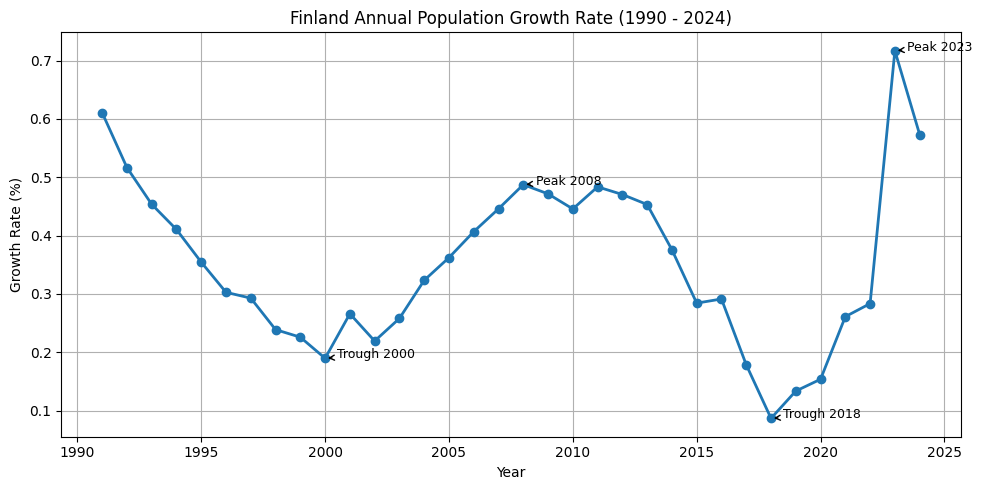

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot line
ax.plot(
    national["year"],
    national["pop_change_rate"] * 100,
    marker="o",
    linewidth=2
)

# Key turning points
key_points = {
    2000: "Trough",
    2008: "Peak",
    2018: "Trough",
    2023: "Peak",
}

for yr, label in key_points.items():
    val = national.loc[national["year"] == yr, "pop_change_rate"].values[0] * 100
    
    ax.annotate(
        f"{label} {yr}",
        xy=(yr, val),
        xytext=(yr + 0.5, val),
        arrowprops=dict(arrowstyle="->"),
        fontsize=9
    )

# Axis & labels
ax.set_title("Finland Annual Population Growth Rate (1990 - 2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Growth Rate (%)")

ax.grid(True)

plt.tight_layout()
plt.show()

### 3.2 Natural increase vs net migration

#### Chart 2: Why does the growth rate have such turning points?
- Natural increase:
    - In 1990, it was stable, with approximately 16,000 people born each year, meaning births significantly exceeded deaths.
    - But since then, it has steadily declined, very slowly but without stopping.
    - Around 2016, it hit zero, meaning for the first time, the number of deaths began to exceed the number of births.
    - After that, it not only went negative, but became even more deeply negative. In recent years (2022–2024), it has dropped to around -20,000.
- Net migration:
    - The period from 1990 to 2015 was quite stable, fluctuating around a few thousand to 15,000 or 18,000 per year.
    - But from around 2016 onwards, it started to become significantly more important.
    - Especially in 2022 - 2023: it surged to approximately 57,000.
- I also noticed that before 2016, population growth was due to births exceeding deaths and migration. But after 2016, natural increase turned negative, that means without migration, the population would have already decreased.

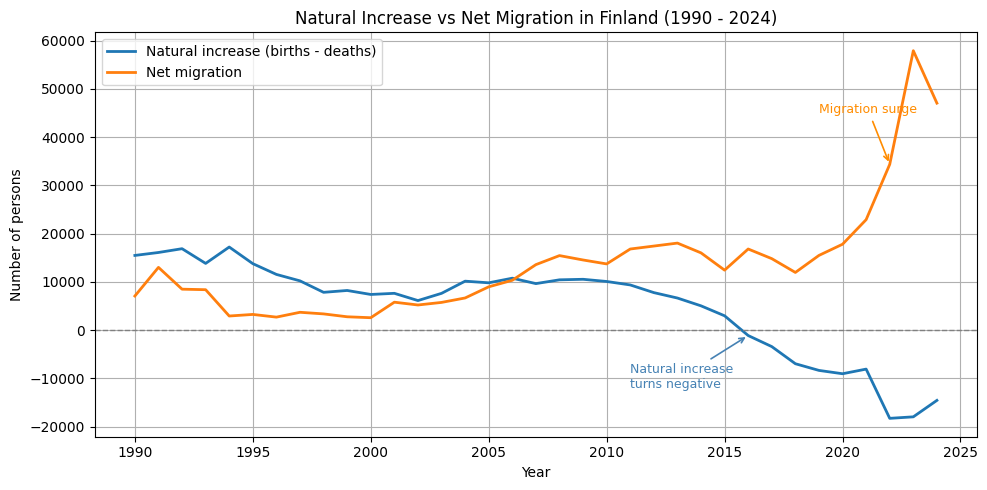

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(national_detail["year"], national_detail["natural_increase"],
        label="Natural increase (births - deaths)", linewidth=2)
ax.plot(national_detail["year"], national_detail["net_migration"],
        label="Net migration", linewidth=2)

ax.axhline(0, linestyle="--", linewidth=1, color="gray")

# point 1: natural increase below 0
ax.annotate("Natural increase\nturns negative",
    xy=(2016, national_detail.loc[national_detail["year"]==2016, "natural_increase"].values[0]),
    xytext=(2011, -12000),
    fontsize=9, color="steelblue",
    arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.2))

# point 2: migration surge
ax.annotate("Migration surge",
    xy=(2022, national_detail.loc[national_detail["year"]==2022, "net_migration"].values[0]),
    xytext=(2019, 45000),
    fontsize=9, color="darkorange",
    arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.2))

ax.set_title("Natural Increase vs Net Migration in Finland (1990 - 2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of persons")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

### 3.3 Aging vs growth (scatter)

#### Chart 3: Where do places age quickly but still grow?
- I want to try searching for paradoxes in the data, to see if there are places that are aging rapidly but still have population growth.

- First, I define rapid aging and growth as a number:
    - Aging: aging_delta = aging_rate(2024) - aging_rate(2014)
    - Growth: pop_growth = (pop_total(2024) - pop_total(2014)) / pop_total(2014)
    - I use 10 years because it's long enough to see the trend and isn't affected by 1-2 year fluctuations.

- After that, I found a threshold for filtering:
    - Using median aging_delta as a threshold for rapid aging quickly:
        - median_aging_delta = compare["aging_delta"].median() # = 0.0647
    - Reason for using median instead of a fixed number: median automatically adapts to the data — always dividing the 308 municipalities into two equal groups, regardless of how the data is distributed.

- The results:
    - Filter: aging_delta > median AND pop_growth > 0, which shows 3 municipalities.

        - Almost no places are both aging rapidly and growing.
    - Trying to loosen the threshold further with the top 25%:

        - threshold_25 = compare["aging_delta"].quantile(0.75) # = 0.0841. The result shows 0 municipalities.
        - This result also tell agian the finding: the fastest aging places are all losing population — without exception.

- Instead of displaying just 3 points, the decision was made to plot all 308 municipalities on a scatter plot because:
    - 3 points are not enough to show the overall pattern.
    - A scatter plot shows the relationship between two variables, much more intuitive than a table of numbers.
    - The 3 exceptions perhaps will stand out more when placed in the context of 308 points.

In [ ]:
# Find municipalities: rapid aging but still growing.

# Use 2014 and 2024 to calculate delta.
df_2014 = df[df["year"] == 2014][["area", "aging_rate", "pop_total"]].set_index("area")
df_2024 = df[df["year"] == 2024][["area", "aging_rate", "pop_total"]].set_index("area")

# Calculate the delta aging rate and pop growth rate over 10 years.
compare = pd.DataFrame({
    "aging_delta":  df_2024["aging_rate"] - df_2014["aging_rate"],
    "pop_growth":   (df_2024["pop_total"] - df_2014["pop_total"]) / df_2014["pop_total"]
}).dropna()

# filter: rapid aging (aging_delta > median) and still (pop_growth > 0)
median_aging_delta = compare["aging_delta"].median()

paradox = compare[
    (compare["aging_delta"] > median_aging_delta) &
    (compare["pop_growth"] > 0)
].sort_values("aging_delta", ascending=False)

print(f"Median aging delta: {median_aging_delta:.4f}")
print(f"Municipalities found: {len(paradox)}")
print("\nTop 15:")
print(paradox.head(15).to_string())

Median aging delta: 0.0647
Municipalities found: 3

Top 15:
            aging_delta  pop_growth
area                               
Kustavi        0.080031    0.087444
Naantali       0.068310    0.066663
Taivassalo     0.065417    0.028571


In [ ]:
#Loosen: top 25% aging delta AND pop_growth > 0
threshold_25 = compare["aging_delta"].quantile(0.75)

paradox2 = compare[
    (compare["aging_delta"] > threshold_25) &
    (compare["pop_growth"] > 0)
].sort_values("aging_delta", ascending=False)

print(f"Top 25% aging delta threshold: {threshold_25:.4f}")
print(f"Municipalities found: {len(paradox2)}")
print("\nAll results:")
print(paradox2.to_string())

Top 25% aging delta threshold: 0.0841
Municipalities found: 0

All results:
Empty DataFrame
Columns: [aging_delta, pop_growth]
Index: []


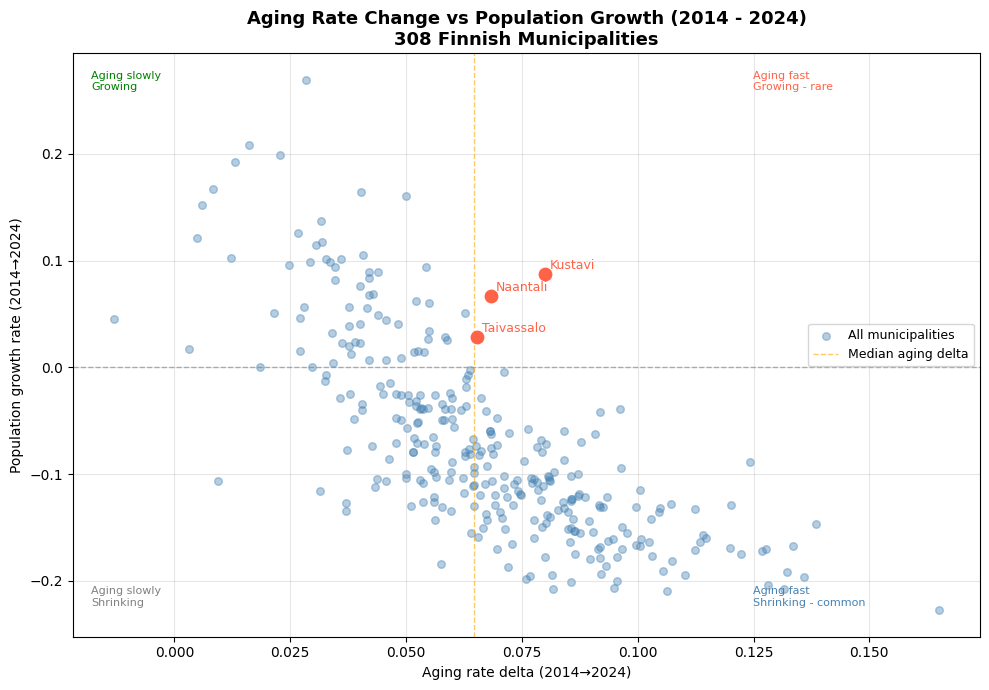

In [ ]:
#EDA Chart 3: Aging delta vs Population growth (scatter) ===
fig, ax = plt.subplots(figsize=(10, 7))

# all municipalities
ax.scatter(compare["aging_delta"], compare["pop_growth"],
           alpha=0.4, color="steelblue", s=30, label="All municipalities")

# 3 exception
paradox_areas = ["Kustavi", "Naantali", "Taivassalo"]
for area in paradox_areas:
    x = compare.loc[area, "aging_delta"]
    y = compare.loc[area, "pop_growth"]
    ax.scatter(x, y, color="tomato", s=80, zorder=5)
    ax.annotate(area, xy=(x, y), xytext=(x + 0.001, y + 0.005),
                fontsize=9, color="tomato")

# dividing line
ax.axhline(0, color="gray", linewidth=1, linestyle="--", alpha=0.6)
ax.axvline(median_aging_delta, color="orange", linewidth=1,
           linestyle="--", alpha=0.6, label=f"Median aging delta")

# Label 4 corner
ax.text(0.02, 0.97, "Aging slowly\nGrowing", transform=ax.transAxes,
        fontsize=8, color="green", va="top")
ax.text(0.75, 0.97, "Aging fast\nGrowing - rare", transform=ax.transAxes,
        fontsize=8, color="tomato", va="top")
ax.text(0.02, 0.05, "Aging slowly\nShrinking", transform=ax.transAxes,
        fontsize=8, color="gray", va="bottom")
ax.text(0.75, 0.05, "Aging fast\nShrinking - common", transform=ax.transAxes,
        fontsize=8, color="steelblue", va="bottom")

ax.set_title("Aging Rate Change vs Population Growth (2014 - 2024)\n"
             "308 Finnish Municipalities",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Aging rate delta (2014→2024)")
ax.set_ylabel("Population growth rate (2014→2024)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Finding: 3 municipalities that are both aging rapidly and experiencing population growth

Kustavi, Naantali, and Taivassalo are the only three out of 308 municipalities that simultaneously satisfy: aging_delta > median AND pop_growth > 0 (2014–2024).

All three share the following characteristics:
    - Negative natural increase: the number of deaths exceeds the number of births.
    - Positive and increasing net migration: migration fully compensates for the population decline.

This means the population growth is NOT due to high birth rates, but because migration attracts new residents, even as the population is aging.

This is only the case for 3 out of 308,an exception, not the rule. Most rapidly aging municipalities are experiencing population loss simultaneously.

In [ ]:
# This code is to view details of 3 municipalities.
areas = ["Kustavi", "Naantali", "Taivassalo"]

for area in areas:
    d = df[df["area"] == area][["year", "pop_total", "aging_rate", 
                                 "births", "deaths", "natural_increase",
                                 "immigration", "net_migration"]]
    print(f"\n--{area}--")
    print(d[d["year"].isin([2014, 2018, 2021, 2024])].to_string())


--Kustavi--
      year  pop_total  aging_rate  births  deaths  natural_increase  immigration  net_migration
4154  2014      892.0    0.350897     4.0    13.0              -9.0          3.0            3.0
4158  2018      926.0    0.381210     4.0    21.0             -17.0          2.0            1.0
4161  2021      971.0    0.403708     3.0    16.0             -13.0          7.0            7.0
4164  2024      970.0    0.430928     1.0    12.0             -11.0         10.0           10.0

--Naantali--
      year  pop_total  aging_rate  births  deaths  natural_increase  immigration  net_migration
5904  2014    18871.0    0.216205   167.0   159.0               8.0         57.0           17.0
5908  2018    19245.0    0.249000   105.0   198.0             -93.0         69.0           35.0
5911  2021    19579.0    0.271056   142.0   225.0             -83.0         70.0           55.0
5914  2024    20129.0    0.284515   157.0   217.0             -60.0        111.0           71.0

--Taivassalo

## 4. Interpretation

### 4.1 Which regions are aging fastest?

- Before creating the chart, I wanted to examine which cities are aging fastest over the past 10 years.
- I used `aging_delta` to measure the rate of increase in the aging rate from 2014 to 2024, then sorted the cities from highest to lowest, keeping the top 15.
- I also added `aging_rate` for 2024, as I wanted to know not only who is aging fast but also how old they are now.


In [ ]:
#check top 15 aging fastest
aging_fastest = compare["aging_delta"].sort_values(ascending=False).head(15).reset_index()
aging_fastest.columns = ["area", "aging_delta"]

# Thêm aging_rate 2024 để biết họ đang ở mức nào
aging_2024 = df[df["year"] == 2024][["area", "aging_rate"]]
aging_fastest = aging_fastest.merge(aging_2024, on="area")

print(aging_fastest.to_string())

           area  aging_delta  aging_rate
0      Rääkkylä     0.164978    0.483254
1         Tervo     0.138460    0.448847
2    Hyrynsalmi     0.135913    0.466034
3      Kumlinge     0.133454    0.432234
4       Hartola     0.132262    0.446817
5         Posio     0.131581    0.451703
6     Ilomantsi     0.128154    0.466454
7   Suomussalmi     0.127603    0.426684
8       Keitele     0.126850    0.424181
9       Puumala     0.124304    0.481199
10     Kyyjärvi     0.122327    0.410390
11        Kitee     0.120042    0.410412
12     Puolanka     0.119915    0.443923
13    Tuusniemi     0.114659    0.417568
14         Simo     0.114132    0.372930


#### Chart 4: Which regions are aging fastest?

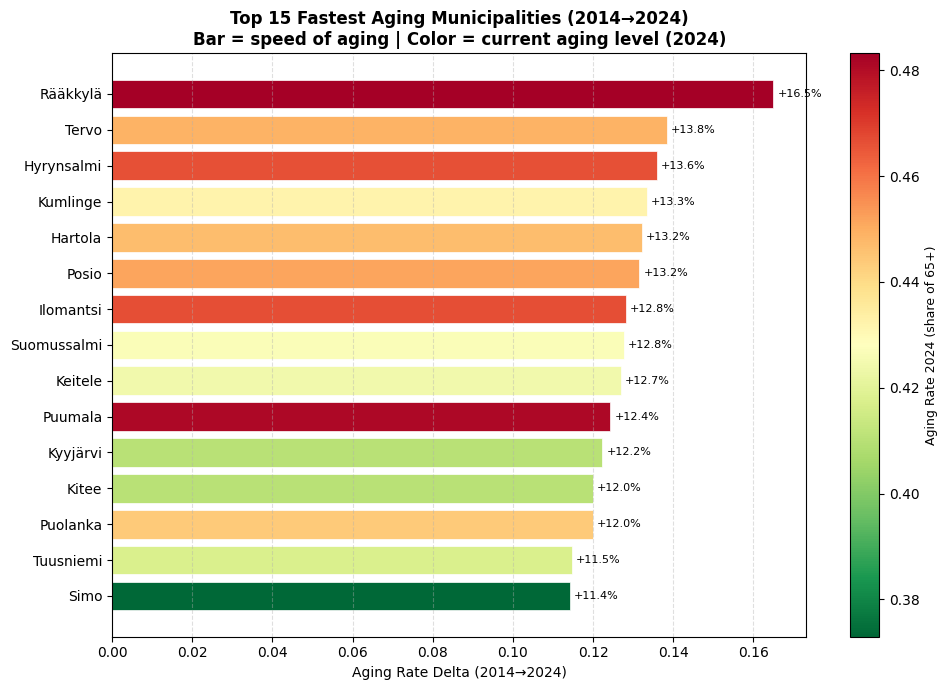

In [ ]:

import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(10, 7))

# color by aging_rate 2024
norm = mcolors.Normalize(vmin=aging_fastest["aging_rate"].min(),
                          vmax=aging_fastest["aging_rate"].max())
colors = cm.RdYlGn_r(norm(aging_fastest["aging_rate"].values))

bars = ax.barh(aging_fastest["area"], aging_fastest["aging_delta"],
               color=colors, edgecolor="white", linewidth=0.5)

# Colorbar
sm = cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Aging Rate 2024 (share of 65+)", fontsize=9)

# Value labels
for bar, val in zip(bars, aging_fastest["aging_delta"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"+{val:.1%}", va="center", fontsize=8)

ax.set_title("Top 15 Fastest Aging Municipalities (2014→2024)\n"
             "Bar = speed of aging | Color = current aging level (2024)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Aging Rate Delta (2014→2024)")
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

- The colors in the chart represent the level of population aging in 2024 (the proportion of the population aged 65 and over).
    - Red = very high aging rate (older population)
    - Green = relatively low aging rate
    
- The fastest aging places in Finland are mostly small municipalities, not large cities.
- Rääkkylä tops the list, with its aging rate increasing by approximately 16.5 percentage points in just 10 years. By 2024, almost half of its population will be 65 years or older.

### 4.2 Which municipalities grow/decline most?

- Before I start drawing, I want to look at the data and check the top 10.

- The results are:
    - Growing: Espoo, Vantaa, and Tampere are large cities. I don't know if Jomala is a large city.
    - Declining: The entire countryside and Rääkkylä reappear, aging the fastest (Chart 4) and losing the most population.

In [ ]:
#check top 10 growing and top 10 decling
growth_2014_2024 = compare["pop_growth"].sort_values(ascending=False)

top10_growth  = growth_2014_2024.head(10)
top10_decline = growth_2014_2024.tail(10)

print("TOP 10 GROWING:")
print(top10_growth.to_string())
print("\nTOP 10 DECLINING:")
print(top10_decline.to_string())

TOP 10 GROWING:
area
Jomala       0.269518
Espoo        0.208584
Sipoo        0.199222
Vantaa       0.191961
Tampere      0.166706
Kempele      0.163894
Järvenpää    0.160461
Larsmo       0.152144
Kaarina      0.136960
Pirkkala     0.125903

TOP 10 DECLINING:
area
Hyrynsalmi   -0.195984
Miehikkälä   -0.197833
Parikkala    -0.199702
Rautavaara   -0.200792
Ilomantsi    -0.203852
Siikainen    -0.206529
Posio        -0.207817
Soini        -0.208095
Multia       -0.209870
Rääkkylä     -0.227515


- Because data can be unpredictable, drawing charts without previewing them beforehand can result in errors or misleading information without realizing it.

- Explanation of each column:
    - `pop_change`: Absolute increase/decrease in population 2014-2024
    - `natural_pct`: Total natural increase over 10 years / population in 2014
    - `migration_pct`: Total net migration over 10 years / population in 2014

In [ ]:
#check breakdown causes of increase/decrease
top10_areas = top10_growth.index.tolist() + top10_decline.index.tolist()

breakdown = df[df["area"].isin(top10_areas)].groupby("area").agg(
    total_natural=("natural_increase", "sum"),
    total_migration=("net_migration", "sum"),
    pop_2014=("pop_total", "first"),
    pop_2024=("pop_total", "last")
).reset_index()

breakdown["pop_change"] = breakdown["pop_2024"] - breakdown["pop_2014"]
breakdown["natural_pct"] = breakdown["total_natural"] / breakdown["pop_2014"]
breakdown["migration_pct"] = breakdown["total_migration"] / breakdown["pop_2014"]

print(breakdown[["area", "pop_change", "natural_pct", "migration_pct"]].to_string())

          area  pop_change  natural_pct  migration_pct
0        Espoo    148302.0     0.395333       0.235047
1   Hyrynsalmi     -2064.0    -0.200689       0.021151
2    Ilomantsi     -3672.0    -0.275515       0.039856
3       Jomala      2764.0     0.274711       0.068430
4    Järvenpää     15346.0     0.260777       0.082506
5      Kaarina     12161.0     0.198401       0.033374
6      Kempele      9850.0     0.564393       0.017029
7       Larsmo      2220.0     0.665120       0.044487
8   Miehikkälä     -1084.0    -0.314316       0.055615
9       Multia     -1014.0    -0.259244       0.026589
10   Parikkala     -3593.0    -0.306094       0.025719
11    Pirkkala      9633.0     0.303795       0.048120
12       Posio     -2600.0    -0.185287       0.025922
13  Rautavaara     -1564.0    -0.265704       0.012093
14    Rääkkylä     -1675.0    -0.293870       0.039933
15   Siikainen     -1087.0    -0.237771       0.017865
16       Sipoo      8155.0     0.137618       0.053575
17       S

#### Chart 5: Why do municipalities grow or decline?

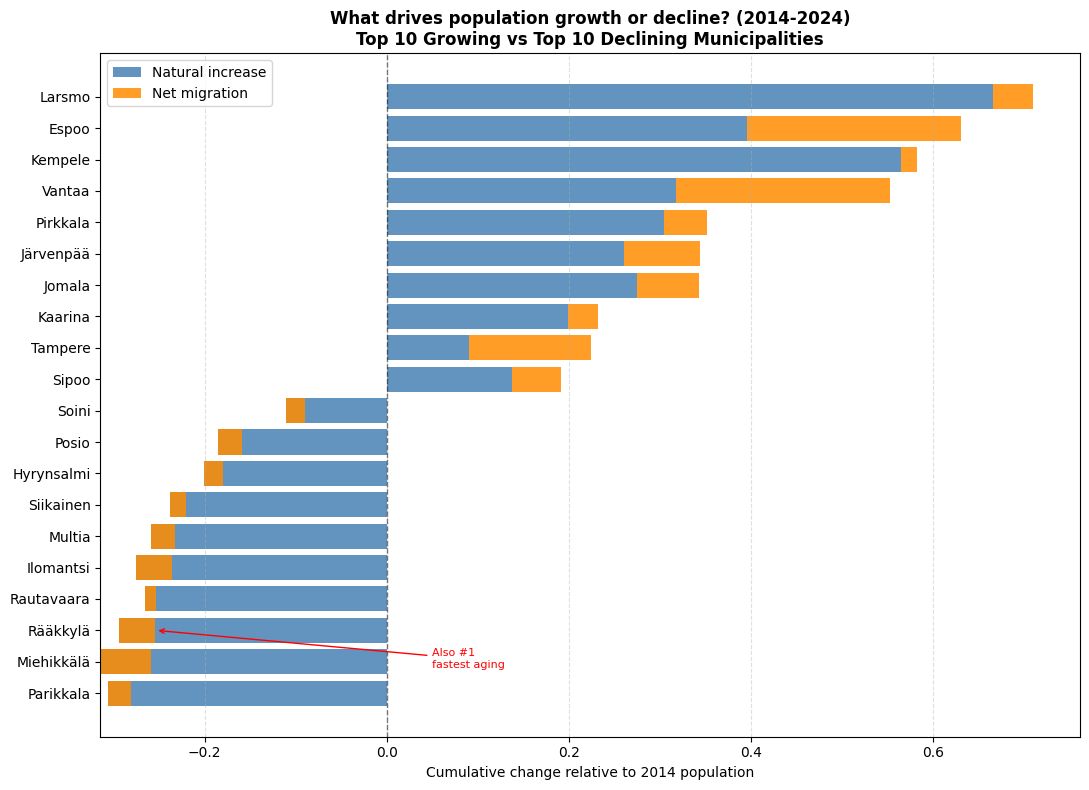

In [ ]:
# Sort by pop_growth for easier chart reading.
breakdown["total_pct"] = breakdown["natural_pct"] + breakdown["migration_pct"]
breakdown_sorted = breakdown.sort_values("total_pct", ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))

# Stacked bar: natural + migration
bars_natural = ax.barh(breakdown_sorted["area"], breakdown_sorted["natural_pct"],
                        color="steelblue", label="Natural increase", alpha=0.85)
bars_migration = ax.barh(breakdown_sorted["area"], breakdown_sorted["migration_pct"],
                          left=breakdown_sorted["natural_pct"],
                          color="darkorange", label="Net migration", alpha=0.85)

# 0 line
ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)

# Highlight Rääkkylä, Both Chart 4 and Chart 5 appear
for i, area in enumerate(breakdown_sorted["area"]):
    if area == "Rääkkylä":
        ax.annotate("Also #1\nfastest aging",
            xy=(breakdown_sorted.loc[breakdown_sorted["area"]==area, "total_pct"].values[0], i),
            xytext=(0.05, i - 1.2),
            fontsize=8, color="red",
            arrowprops=dict(arrowstyle="->", color="red", lw=1))

ax.set_title("What drives population growth or decline? (2014-2024)\n"
             "Top 10 Growing vs Top 10 Declining Municipalities",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Cumulative change relative to 2014 population")
ax.legend(fontsize=10)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

How to Read the Chart

- Each horizontal bar represents a municipality.
    - Blue (Natural increase) = (number of births - number of deaths) during the period 2014-2024
    - Orange (Net migration) = (number of people moving in - number of people leaving)

- Total bar length = total population change

- A bar to the right (positive) represents population increase.

- A bar to the left (negative) represents population decrease.

- The vertical line in the middle (x = 0) is the reference point:

    - Right meaing growth

    - Left meaing decline

- Findings:
- There are two completely different types of growth.
    - Large cities group (Espoo, Vantaa, Tampere)
        - Orange (migration) accounts for the majority
        - Indicates growth is mainly due to people moving in.
        - Perhaps large city in Finland cities thrive by attracting a large population, rather than by having high birth rates? I guess so..
    - Small area groups (Larsmo, Kempele)
        - Green (natural growth) accounts for almost all of them
        - Surprisingly, some small areas still have high birth rates, creating natural growth, because I thought growth was usually due to migration.

- Looking at the group experiencing population decline (on the left):
    - They all have: Very large negative natural increase and small or even positive migration.
    - Most rural areas are not experiencing population decline because people are leaving,but because of an aging population and a death rate exceeding the birth rate.

- about Rääkkylä:
    - Appears in the group with the most significant decline
    - Also (Chart 4) is the area with the fastest aging

- I see two contrasting growth patterns:
    - Espoo: Balanced between natural growth and migration
    - Larsmo: Almost entirely due to natural growth

### 4.3 NEED UPdate!!!!
How do birth rates compare to immigration as drivers of population change?

→ Answered by Chart 2 (Natural Increase vs Net Migration, 1990–2024)

**Conclusion from data:**

Before 1998: natural increase > net migration
→ Population growth was mainly driven by births exceeding deaths.

1998–2015: the two lines gradually converge
→ Natural increase declines while migration increases,
→ both factors contribute more equally over time.

After 2016: natural increase drops below 0
→ For the first time in modern history, deaths exceed births.
→ From this point onward, net migration becomes the only driver of population growth.

2022–2023: unusual migration surge (~57,000 net)
→ This offsets a large natural decline (~ -20,000), preventing overall population loss.

**Bottom line:**
Finland has transitioned from natural growth to being
fully dependent on migration within the past decade.
If migration decreases, Finland’s population will begin to shrink.

### 4.4 What parts need more services?

- Prepare data to define service pressure
    - `aging_delta`: how much the aging rate increased between 2014 and 2024
    - `pop_growth`: how much total population changed between 2014 and 2024

- I want to identify municipalities that may face higher service pressure in the future.

- A municipality is more facing service pressure if it is already old, and also negative population growth




- The result show:
    - aging_rate: mean = 31% and 75% percentile = 37% meaning that 1/4 of municipalities have more than 37% of their population aged 65+
    - pop_growth: mean = -6.9%, median = -9% ,more than half of municipalities are losing residents.


In [ ]:
# Check the data first to define service pressure

service = df[df["year"] == 2024][["area", "aging_rate", "pop_total"]].copy()

# Add pop_growth and aging_delta from the compare table
service = service.merge(
    compare[["aging_delta", "pop_growth"]],
    left_on="area",
    right_index=True
)

# Service pressure means municipalities that are both:
# - old (high aging_rate)
# - shrinking (negative pop_growth)
print("Aging rate stats:")
print(service["aging_rate"].describe())

print("\nPop growth stats:")
print(service["pop_growth"].describe())

Aging rate stats:
count    308.000000
mean       0.311877
std        0.076272
min        0.114328
25%        0.257614
50%        0.309280
75%        0.370129
max        0.483254
Name: aging_rate, dtype: float64

Pop growth stats:
count    308.000000
mean      -0.069465
std        0.091634
min       -0.227515
25%       -0.134159
50%       -0.090863
75%       -0.024542
max        0.269518
Name: pop_growth, dtype: float64


Service Pressure Classification:
- Instead of looking at aging or growth individually, Chart 6 combines both to classify the 308 municipalities into four groups: High pressure, Shrinking not old, Aging but growing, and Low pressure.

Results:
- High pressure (n=75, 24%): Aging population + population loss. I think this group needs more elderly care and healthcare services.

- Shrinking not old (54%): This group needs population retention and may need additional migration.
- Low pressure (21%): This group is mostly young, so they may need schools, housing, and infrastructure.

- Aging but growing (1%): This group is quite small and needs both elderly care services and infrastructure development for young people.

In [ ]:
# Define thresholds from the data
aging_threshold = service["aging_rate"].quantile(0.75)   # top 25% oldest municipalities = 0.370
growth_threshold = 0   # simple cutoff: municipality is shrinking if growth is negative

print(f"Aging threshold (75th percentile): {aging_threshold:.3f}")
print(f"Growth threshold: {growth_threshold}")

# Classify each municipality into a service-pressure group
def classify(row):
    old = row["aging_rate"] >= aging_threshold
    shrink = row["pop_growth"] < growth_threshold

    if old and shrink:
        return "High pressure"      # old + shrinking -> highest future service pressure
    elif old and not shrink:
        return "Aging but growing"  # old but still growing
    elif not old and shrink:
        return "Shrinking not old"  # shrinking, but not yet among the oldest
    else:
        return "Low pressure"       # relatively younger and growing

service["pressure"] = service.apply(classify, axis=1)

print("\nDistribution:")
print(service["pressure"].value_counts())

print("\nHigh pressure sample:")
print(
    service[service["pressure"] == "High pressure"]
    .sort_values("aging_rate", ascending=False)
    .head(10)[["area", "aging_rate", "pop_growth"]]
    .to_string()
)

Aging threshold (75th percentile): 0.370
Growth threshold: 0

Distribution:
pressure
Shrinking not old    167
High pressure         75
Low pressure          64
Aging but growing      2
Name: count, dtype: int64

High pressure sample:
            area  aging_rate  pop_growth
8154    Rääkkylä    0.483254   -0.227515
7314     Puumala    0.481199   -0.088899
3989   Kuhmoinen    0.473503   -0.141533
1679   Ilomantsi    0.466454   -0.203852
1364  Hyrynsalmi    0.466034   -0.195984
9169       Sysmä    0.462369   -0.163290
7139       Posio    0.451703   -0.207817
9414       Tervo    0.448847   -0.146896
5179     Luhanka    0.448664   -0.065703
1154   Heinävesi    0.446910   -0.194887


#### Chart 6: What parts need more services?

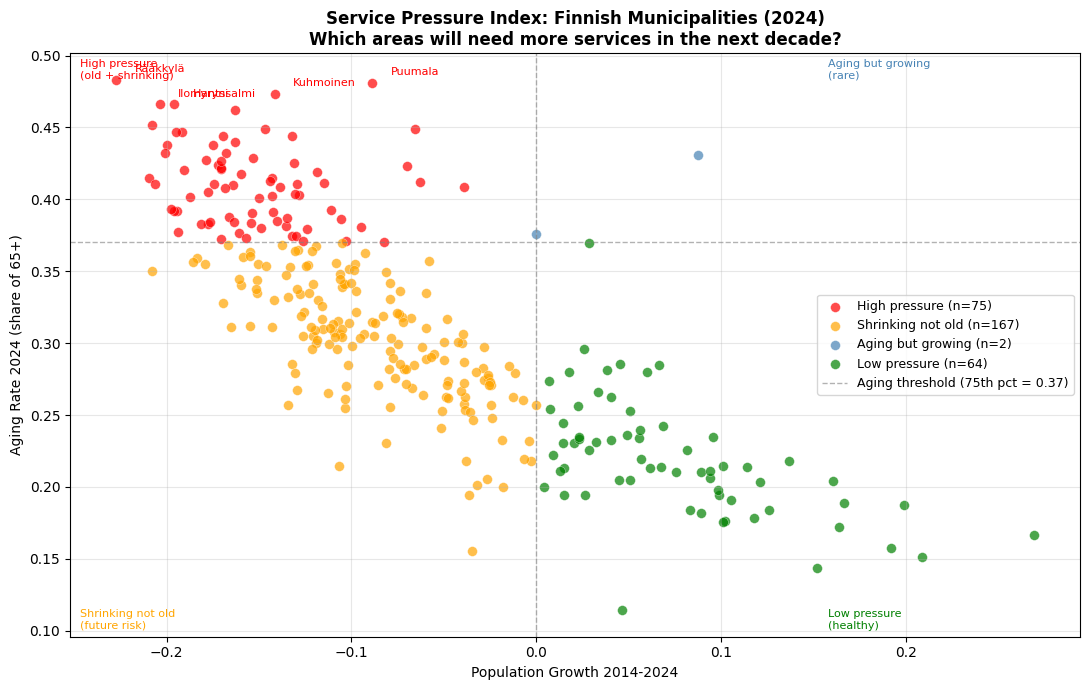

In [ ]:
#Chart 6: Service Pressure Map
fig, ax = plt.subplots(figsize=(11, 7))

colors_map = {
    "High pressure":      "red",
    "Shrinking not old":  "orange",
    "Aging but growing":  "steelblue",
    "Low pressure":       "green"
}

for group, color in colors_map.items():
    mask = service["pressure"] == group
    ax.scatter(service.loc[mask, "pop_growth"],
               service.loc[mask, "aging_rate"],
               c=color, label=f"{group} (n={mask.sum()})",
               alpha=0.7, s=50, edgecolors="white", linewidth=0.3)

# dividing line
ax.axhline(aging_threshold, color="gray", linestyle="--",
           linewidth=1, alpha=0.6, label=f"Aging threshold (75th pct = {aging_threshold:.2f})")
ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.6)

# Highlight top 5 high pressure
top5 = service[service["pressure"] == "High pressure"].nlargest(5, "aging_rate")
for _, row in top5.iterrows():
    ax.annotate(row["area"],
        xy=(row["pop_growth"], row["aging_rate"]),
        xytext=(row["pop_growth"] + 0.01, row["aging_rate"] + 0.005),
        fontsize=8, color="red")

# Label
ax.text(0.01, 0.99, "High pressure\n(old + shrinking)",
        transform=ax.transAxes, fontsize=8, color="red",
        va="top", ha="left")
ax.text(0.75, 0.99, "Aging but growing\n(rare)",
        transform=ax.transAxes, fontsize=8, color="steelblue",
        va="top", ha="left")
ax.text(0.01, 0.01, "Shrinking not old\n(future risk)",
        transform=ax.transAxes, fontsize=8, color="orange",
        va="bottom", ha="left")
ax.text(0.75, 0.01, "Low pressure\n(healthy)",
        transform=ax.transAxes, fontsize=8, color="green",
        va="bottom", ha="left")

ax.set_title("Service Pressure Index: Finnish Municipalities (2024)\n"
             "Which areas will need more services in the next decade?",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Population Growth 2014-2024")
ax.set_ylabel("Aging Rate 2024 (share of 65+)")
ax.legend(fontsize=9, loc="center right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Some findings:
- Up to 75 municipalities are in high pressure, mostly in rural areas.
- Aging and population decline always occur together.
- The "shrinking but not old" group is the largest, meaning that even though many areas do not yet have an aging population, they seem likely to become high pressure areas sooner or later.

## 5. Forecasting Model

### Objective
Forecast Finland’s total population for the period 2025–2040,  
focusing on the key question:

> "How is Finland's population likely to change over the next 10–20 years?"

---

### Approach
I build simple models directly from the data to better understand the underlying trends.

The forecast is performed at the **national level**,  
by aggregating all 308 municipalities into a single time series.

---

### Models for Comparison

| Model | Data | Purpose |
|------|------|--------|
| Linear (full) | 1990-2024 | Represents continuation of recent trend |
| Linear (pre-spike) | 1990-2021 | Baseline trend without recent shock |
| Polynomial (degree 2, full) | 1990-2024 | Captures potential non-linear trends (acceleration/deceleration) |

The differences between these models reflect the level of uncertainty in the forecast,  
particularly depending on whether recent migration-driven growth continues.

---

### Pipeline

1. Create national time series  
2. Visualize historical trend  
3. Prepare input features (X, y)  
4. Train three models  
5. Predict population for 2025 - 2040  
6. Visualize forecast results  
7. Interpret outcomes  

### Step 1: create national time series
- The model only accepts a single line as input, it cannot accept 308 lines simultaneously, so they must be grouped together first.

In [ ]:
#create national time series
national_ts = df.groupby("year")["pop_total"].sum().reset_index()
national_ts.columns = ["year", "pop_total"]

print(national_ts.to_string())

    year  pop_total
0   1990  4998478.0
1   1991  5029002.0
2   1992  5054982.0
3   1993  5077912.0
4   1994  5098754.0
5   1995  5116826.0
6   1996  5132320.0
7   1997  5147349.0
8   1998  5159646.0
9   1999  5171302.0
10  2000  5181115.0
11  2001  5194901.0
12  2002  5206295.0
13  2003  5219732.0
14  2004  5236611.0
15  2005  5255580.0
16  2006  5276955.0
17  2007  5300484.0
18  2008  5326314.0
19  2009  5351427.0
20  2010  5375276.0
21  2011  5401267.0
22  2012  5426674.0
23  2013  5451270.0
24  2014  5471753.0
25  2015  5487308.0
26  2016  5503297.0
27  2017  5513130.0
28  2018  5517919.0
29  2019  5525292.0
30  2020  5533793.0
31  2021  5548241.0
32  2022  5563970.0
33  2023  5603851.0
34  2024  5635971.0


### Step 2: Visualize historical trend

- Before building any model let see the data. This will helps me understand the long term trend and detect unusual patterns.

- From the chart:
    - 1990–2018: steady population growth (almost linear)
    - 2019–2021: growth slows down
    - 2022–2024: a noticeable spike

- The spike in 2022-2023 is likely driven by migration (maybe because Ukraine-related inflow).

- So, we will later compare models with and without this spike.

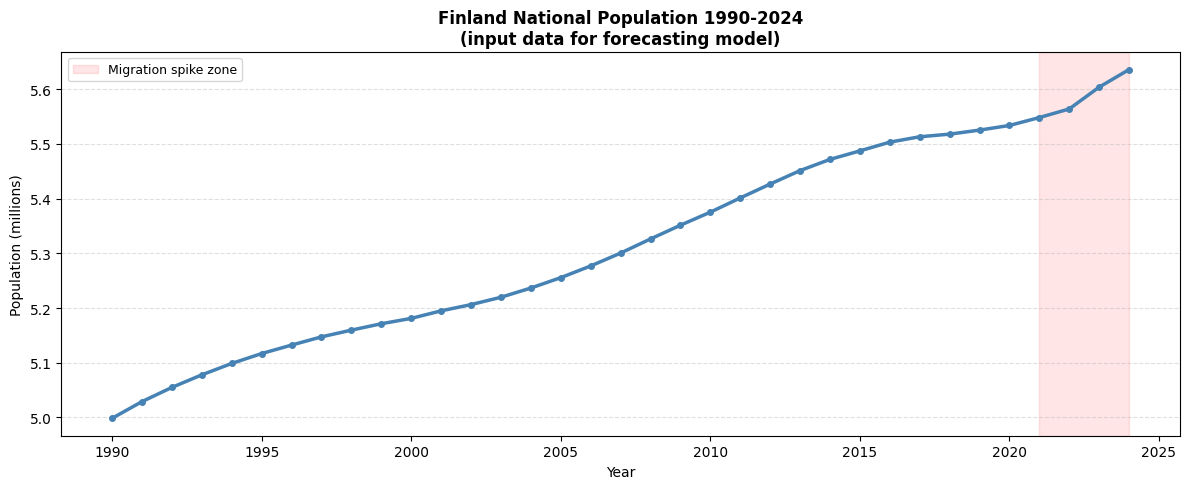

In [ ]:
# Visualize historical trend
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(national_ts["year"], national_ts["pop_total"] / 1e6,
        color="steelblue", linewidth=2.5, marker="o", markersize=4)

# Highlight spike
ax.axvspan(2021, 2024, alpha=0.1, color="red", label="Migration spike zone")

ax.set_title("Finland National Population 1990-2024\n(input data for forecasting model)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Population (millions)")
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Step3: Prepare X and Y


- **X = year** (independent variable)  
- **y = pop_total** (dependent variable)  

- **X_full:** 1990–2024 (35 years): used for Model A and Model C  
- **X_pre:** 1990–2021 (32 years): used for Model B (spike removed)  
- **X_future:** 2025–2040 (16 years):input for prediction  

In [ ]:
#X, y and X_future
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# X and y, for full data
X_full = national_ts["year"].values.reshape(-1, 1)
y_full = national_ts["pop_total"].values

# X and y for pre spike (1990-2021)
mask_pre = national_ts["year"] <= 2021
X_pre  = national_ts.loc[mask_pre, "year"].values.reshape(-1, 1)
y_pre  = national_ts.loc[mask_pre, "pop_total"].values

# X_future from 2025 to 2040
X_future = np.arange(2025, 2041).reshape(-1, 1)

# check ouput
print("X_full shape:", X_full.shape)
print("X_pre shape: ", X_pre.shape)
print("X_future:    ", X_future.flatten())

X_full shape: (35, 1)
X_pre shape:  (32, 1)
X_future:     [2025 2026 2027 2028 2029 2030 2031 2032 2033 2034 2035 2036 2037 2038
 2039 2040]


### Step 4: Train 3 models

| | Model A | Model B | Model C |
|---|---|---|---|
| Type | Linear | Linear | Polynomial |
| Data | 1990-2024 | 1990-2021 | 1990-2024 |
| Shape | Straight line | Straight line | Curved line |
| Scenerio | High migration | Normal migration | Non linear trend |


- The model here is not a Neural Network or Deep Learning, it's a Statistical Regression Model, that learns from past data to predict the future.
- It's lile I draw a line through from 1990 to 2024, and will find out where will that line go in 2040.
- Model A and B are both linear, they assume that the growth rate remains constant over time. However, the real data is not linear,we can see here:
    - 1990-2008: rapid growth
    - 2008-2019: slowdown
    - 2019-2024: sharp increase
- So, Model C (Polynomial) will captures this non linear shape

In [ ]:
# Train 3 models

#model A: Linear Regression, full data (1990-2024)
model_A = LinearRegression()
model_A.fit(X_full, y_full)

#Model B: Linear Regression, pre spike (1990-2021)
model_B = LinearRegression()
model_B.fit(X_pre, y_pre)

#Model C: seoncd polynomial Regression, full data
poly = PolynomialFeatures(degree=2)
X_full_poly = poly.fit_transform(X_full)
model_C = LinearRegression()
model_C.fit(X_full_poly, y_full)

# check coefficients
print("Model A (Linear full):")
print(f"  slope:     {model_A.coef_[0]:,.0f} persons/year")
print(f"  intercept: {model_A.intercept_:,.0f}")

print("\nModel B (Linear pre spike):")
print(f"  slope:     {model_B.coef_[0]:,.0f} persons/year")
print(f"  intercept: {model_B.intercept_:,.0f}")

print("\nModel C (degree 2 Polynomial):")
print(f"  coefficients: {model_C.coef_}")
print(f"  intercept:    {model_C.intercept_:,.0f}")

Model A (Linear full):
  slope:     18,036 persons/year
  intercept: -30,881,836

Model B (Linear pre spike):
  slope:     18,106 persons/year
  intercept: -31,021,619

Model C (degree 2 Polynomial):
  coefficients: [ 0.00000000e+00 -5.32310290e+04  1.77546886e+01]
  intercept:    40,633,109


##### result after train

| Model | Slope | Intercept |
|---|---|---|
| A - Linear full | 18,036 /year | -30,881,836 |
| B - Linear pre-spike | 18,106 /year | -31,021,636 |
| C - Polynomial degree 2 | 17.75 × year² | 40,633,109 |

##### Model A and B are almost identical
- The slopes differ by only ~70 people per year (18,036 vs 18,106), that's means the 2022-2023 spike does not significantly affect the linear trend,
because it only accounts for 3 out of 35 years, not enough weight to shift the model.
- slope of ~18,000 people/year mean on average, Finland’s population increases by about 18,000 people per year.




### Step5: Predict 2025 - 2040

In [ ]:
#Predict 2025–2040

# Model A full
y_pred_A = model_A.predict(X_future)

# Model B, pre spike
y_pred_B = model_B.predict(X_future)

# Model C, Polynomial (need to transform X_future first)
X_future_poly = poly.transform(X_future)
y_pred_C = model_C.predict(X_future_poly)

# check the result
import pandas as pd
forecast_df = pd.DataFrame({
    "year":    X_future.flatten(),
    "Model_A": y_pred_A / 1e6,
    "Model_B": y_pred_B / 1e6,
    "Model_C": y_pred_C / 1e6
}).round(3)

print(forecast_df.to_string())

    year  Model_A  Model_B  Model_C
0   2025    5.642    5.643    5.646
1   2026    5.660    5.662    5.664
2   2027    5.678    5.680    5.683
3   2028    5.696    5.698    5.702
4   2029    5.714    5.716    5.721
5   2030    5.732    5.734    5.739
6   2031    5.750    5.752    5.758
7   2032    5.768    5.770    5.777
8   2033    5.786    5.788    5.796
9   2034    5.804    5.806    5.815
10  2035    5.822    5.824    5.834
11  2036    5.840    5.843    5.853
12  2037    5.858    5.861    5.872
13  2038    5.876    5.879    5.891
14  2039    5.894    5.897    5.911
15  2040    5.912    5.915    5.930


- hmm, interesting, all three models show very similar results for 2040:
    - Model A = 5.912M
    - Model B = 5.915M
    - Model C = 5.930M
- The population is still growing slightly, not like an explosion.


### Step 6: Draw chart

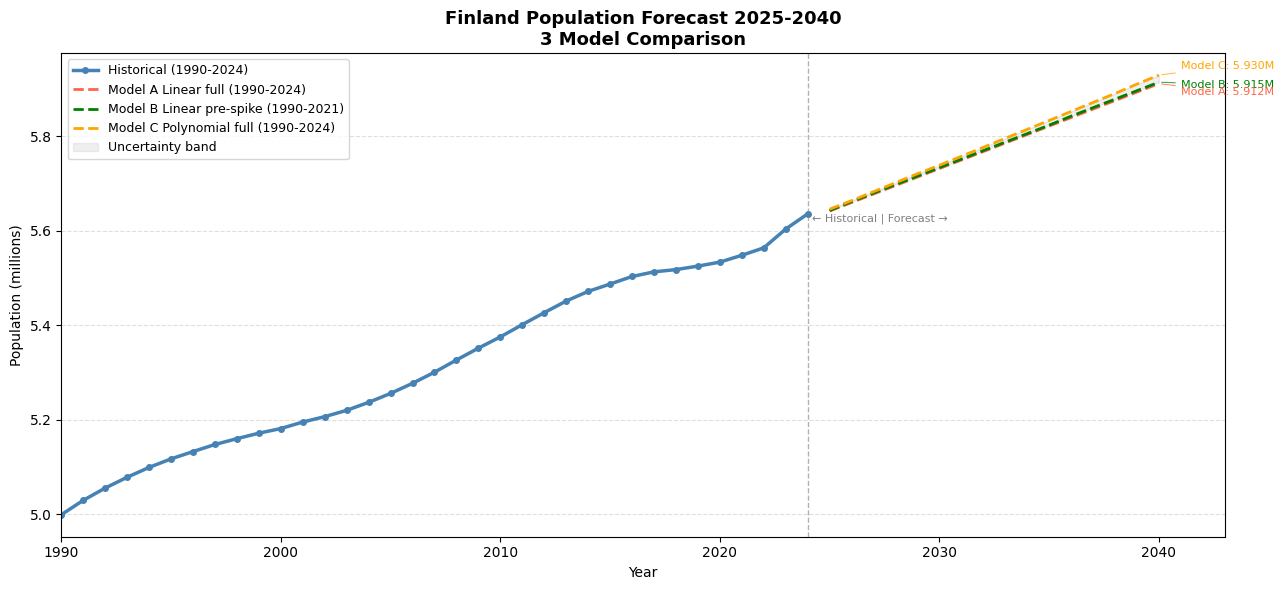

In [ ]:
# draw historical and forecast
fig, ax = plt.subplots(figsize=(13, 6))

# Historical data
ax.plot(national_ts["year"], national_ts["pop_total"] / 1e6,
        color="steelblue", linewidth=2.5, marker="o",
        markersize=4, label="Historical (1990-2024)")

# 3 forecast lines
ax.plot(forecast_df["year"], forecast_df["Model_A"],
        color="tomato", linewidth=2, linestyle="--",
        label="Model A Linear full (1990-2024)")
ax.plot(forecast_df["year"], forecast_df["Model_B"],
        color="green", linewidth=2, linestyle="--",
        label="Model B Linear pre-spike (1990-2021)")
ax.plot(forecast_df["year"], forecast_df["Model_C"],
        color="orange", linewidth=2, linestyle="--",
        label="Model C Polynomial full (1990-2024)")

# Confidence band between B and C
ax.fill_between(forecast_df["year"],
                forecast_df["Model_B"],
                forecast_df["Model_C"],
                alpha=0.12, color="gray", label="Uncertainty band")

# Vertical line for historical / forecast
ax.axvline(2024, color="gray", linewidth=1,
           linestyle="--", alpha=0.6)
ax.text(2024.2, 5.62, "← Historical | Forecast →",
        fontsize=8, color="gray")

# Annotate 2040 values (avoid overlap)
annotations = [
    (forecast_df.loc[15, "Model_C"], "orange", "Model C: 5.930M", 0.019),
    (forecast_df.loc[15, "Model_B"], "green",  "Model B: 5.915M", -0.005),
    (forecast_df.loc[15, "Model_A"], "tomato", "Model A: 5.912M", -0.018),
]

for val, color, label, offset in annotations:
    ax.annotate(label,
        xy=(2040, val),
        xytext=(2041, val + offset),   # shift position
        fontsize=8,
        color=color,
        va="center",
        arrowprops=dict(arrowstyle="-", color=color, lw=0.8, alpha=0.7)
    )

ax.set_title("Finland Population Forecast 2025-2040\n"
             "3 Model Comparison",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Population (millions)")
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_xlim(1990, 2043)

plt.tight_layout()
plt.show()

### step 7: Interpretation, Forecasting Results
- Looking at the chart, Finland's population will continue to grow, reaching approximately 5.91 to 5.93 million people. However, the growth rate depends entirely on migration (as evidenced by chart 2, showing natural negative growth since 2016).
- All three models are similar, showing population growth, with an increase of approximately 280,000 to 290,000 people over 16 years from 2024 to 2040.
- Compared to the period from 1990 to 2010, the growth seems slower from 2024 to 2040: 18,000 people/year compared to 25,000/year.

## 6. CLUSTERING

### Objective
- Instead of manually defining thresholds as in Chart 6 (Classification), clustering let the algorithm to discover natural groupings in the data.
- Clustering will also let us know how do the 308 municipalities naturally group together based on their demographic patterns.

### Difference from Chart 6

| | Chart 6 (Classification) | Clustering |
|---|---|---|
| Thresholds | Defined manually | Learned from data |
| Number of groups | Predefined | Choose k, then let data decide structure |
| Result | Depends on chosen thresholds | Depends on patterns in the data |

To cluster municipalities, I use four features that capture different dimensions of demographic change:

- `aging_rate`: the current share of population aged 65+ in 2024
- `aging_delta`: how much the aging rate increased from 2014 to 2024
- `pop_growth`: population growth/decline from 2014 to 2024
- `migration_pct`: cumulative net migration relative to 2014 population




In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Population in 2014
df_2014 = df[df["year"] == 2014][["area", "pop_total"]].set_index("area")

# Migration 2014-2024 (same window as pop_growth)
df_mig = (
    df[df["year"] >= 2014]
    .groupby("area")["net_migration"]
    .sum()
    .to_frame("total_net_migration")
)

# Build dataset,4 features
cluster_data = pd.DataFrame({
    "aging_rate":    df[df["year"] == 2024].set_index("area")["aging_rate"],
    "aging_delta":   compare["aging_delta"],
    "pop_growth":    compare["pop_growth"],
    "migration_pct": df_mig["total_net_migration"] / df_2014["pop_total"]
}).dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data)


print("Shape:", cluster_data.shape)
print("\nFeatures:", cluster_data.columns.tolist())
print("\nStats:")
print(cluster_data.describe().round(3).to_string())

Shape: (308, 4)

Features: ['aging_rate', 'aging_delta', 'pop_growth', 'migration_pct']

Stats:
       aging_rate  aging_delta  pop_growth  migration_pct
count     308.000      308.000     308.000        308.000
mean        0.312        0.067      -0.069          0.033
std         0.076        0.027       0.092          0.030
min         0.114       -0.013      -0.228         -0.005
25%         0.258        0.050      -0.134          0.014
50%         0.309        0.065      -0.091          0.024
75%         0.370        0.084      -0.025          0.043
max         0.483        0.165       0.270          0.287


In [ ]:
# === CLUSTERING: Train K-Means k=3 ===
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_data["cluster"] = kmeans.fit_predict(X_scaled)

# Xem distribution
print("Cluster distribution:")
print(cluster_data["cluster"].value_counts().sort_index())

# Xem profile từng cluster
print("\nCluster profiles (mean):")
print(cluster_data.groupby("cluster").mean().round(3).to_string())

Cluster distribution:
cluster
0    101
1    131
2     76
Name: count, dtype: int64

Cluster profiles (mean):
         aging_rate  aging_delta  pop_growth  migration_pct
cluster                                                    
0             0.396        0.094      -0.150          0.030
1             0.297        0.063      -0.079          0.025
2             0.226        0.036       0.055          0.049


In [ ]:
# nameing clusters
cluster_names = {
    0: "Aging & Shrinking",
    1: "Stable Declining",
    2: "Growing Urban"
}
cluster_data["cluster_name"] = cluster_data["cluster"].map(cluster_names)